# scFv × EGFR D3 co-fold comparison

Compares AF3 and ESMFold2 co-fold predictions for three Cetuximab scFv variants against EGFR Domain III.

**Structure of analysis:**
1. Scan available results, compare engine confidence scores, pick best engine per variant  
2. Align each predicted EGFR chain against 1YY9 (crystal reference) — measures fold accuracy  
3. Align all variants onto one another (EGFR-anchored) — measures binding-mode consistency  
4. Visualise in PyMOL

## 1. Setup

In [ ]:
import sys, json, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import biotite.structure as struc
import biotite.structure.io.pdb as pdb_io
from biotite.structure import superimpose, rmsd as calc_rmsd

sys.path.insert(0, str(Path("../../src").resolve()))
from pipelines.io import parse_to_atom_array

NOTEBOOK_DIR = Path(".").resolve()
VARIANTS    = ["Cetuximab", "ConvergeAB", "hu225"]
ENGINES     = ["af3", "esm2"]
COLORS      = {"Cetuximab": "#e41a1c", "ConvergeAB": "#377eb8", "hu225": "#4daf4a"}
ENG_COLORS  = {"af3": "#ff7f00", "esm2": "#984ea3"}

# 1YY9 crystal reference — full ectodomain, chain A.
# Cetuximab binds EGFR Domain III; residues 2-165 of deposited 1YY9 chain A
# span the first 164 deposited residues (residue 1 is absent in the crystal).
REF_PDB      = NOTEBOOK_DIR / "1YY9.pdb"
REF_CHAIN    = "A"
REF_RES_MIN  = 2
REF_RES_MAX  = 165

## 2. Utility functions

In [4]:
def load_af3_summary(variant: str) -> dict | None:
    """Return AF3 summary_confidences.json dict for `variant`, or None if absent."""
    p = NOTEBOOK_DIR / "results" / "af3" / variant / "_run" / "af3" / \
        "chunk_0" / "outputs" / f"{variant}_input" / "Cetuximab_input_summary_confidences.json"
    # AF3 names the summary after the job name, not the variant
    base = NOTEBOOK_DIR / "results" / "af3" / variant / "_run" / \
           "af3" / "chunk_0" / "outputs" / f"{variant}_input"
    candidates = list(base.glob("*summary_confidences.json")) if base.exists() else []
    if not candidates:
        return None
    return json.loads(candidates[0].read_text())


def load_esm2_summary(variant: str) -> dict | None:
    p = NOTEBOOK_DIR / "results" / "esm2" / variant / "complex" / \
        "complex_summary_confidences.json"
    return json.loads(p.read_text()) if p.exists() else None


def load_af3_best_cif(variant: str) -> Path | None:
    """Return path to highest-ranked AF3 sample CIF for `variant`."""
    ranking = NOTEBOOK_DIR / "results" / "af3" / variant / "_run" / \
              "af3" / "chunk_0" / "outputs" / f"{variant}_input" / "ranking_scores.csv"
    if not ranking.exists():
        return None
    df = pd.read_csv(ranking)
    best = df.loc[df["ranking_score"].idxmax()]
    seed, sample = int(best["seed"]), int(best["sample"])
    sample_dir = NOTEBOOK_DIR / "results" / "af3" / variant / "_run" / \
                 "af3" / "chunk_0" / "outputs" / f"{variant}_input" / \
                 f"seed-{seed}_sample-{sample}"
    cifs = list(sample_dir.glob("*_model.cif"))
    return cifs[0] if cifs else None


def load_esm2_best_cif(variant: str) -> Path | None:
    """Return path to best ESMFold2 sample CIF for `variant` (always seed-42_sample-0)."""
    p = NOTEBOOK_DIR / "results" / "esm2" / variant / "complex" / \
        "seed-42_sample-0" / "complex_seed-42_sample-0_model.cif"
    return p if p.exists() else None

## 3. Confidence score comparison

In [5]:
rows = []
for v in VARIANTS:
    for eng, fn in [("af3", load_af3_summary), ("esm2", load_esm2_summary)]:
        conf = fn(v)
        if conf is None:
            rows.append(dict(variant=v, engine=eng, ptm=np.nan, iptm=np.nan, ranking_score=np.nan))
        else:
            rows.append(dict(
                variant=v, engine=eng,
                ptm=conf.get("ptm", np.nan),
                iptm=conf.get("iptm", np.nan),
                ranking_score=conf.get("ranking_score", np.nan),
            ))

conf_df = pd.DataFrame(rows)
print(conf_df.to_string(index=False))

   variant engine      ptm     iptm  ranking_score
 Cetuximab    af3 0.580000 0.130000       0.240000
 Cetuximab   esm2 0.659641 0.299892       0.371842
ConvergeAB    af3 0.570000 0.110000       0.220000
ConvergeAB   esm2      NaN      NaN            NaN
     hu225    af3 0.580000 0.100000       0.230000
     hu225   esm2      NaN      NaN            NaN


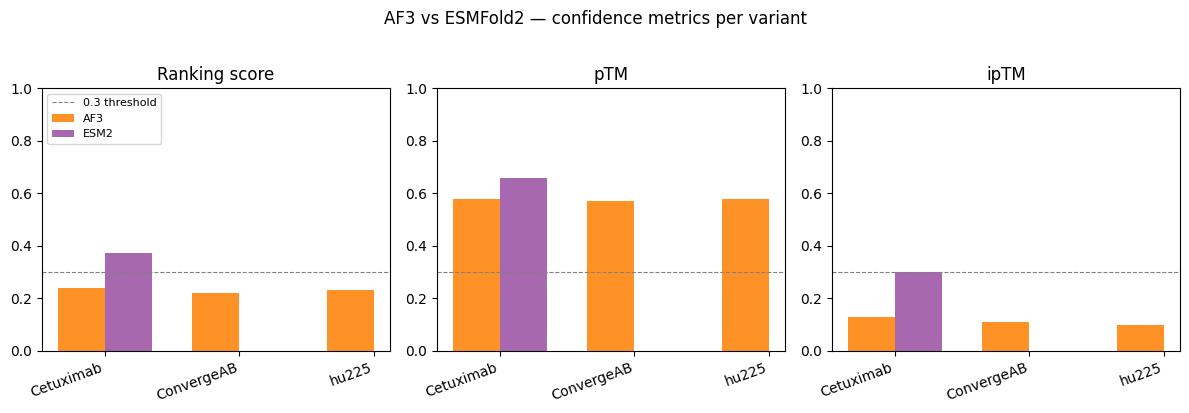

In [6]:
# ── Plot: ranking_score per variant × engine ─────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
metrics = ["ranking_score", "ptm", "iptm"]
metric_labels = ["Ranking score", "pTM", "ipTM"]

for ax, metric, label in zip(axes, metrics, metric_labels):
    sub = conf_df.pivot(index="variant", columns="engine", values=metric)
    x = np.arange(len(VARIANTS))
    w = 0.35
    for i, eng in enumerate(["af3", "esm2"]):
        vals = [sub.loc[v, eng] if v in sub.index else np.nan for v in VARIANTS]
        ax.bar(x + i * w - w / 2, vals, w, label=eng.upper(),
               color=ENG_COLORS[eng], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(VARIANTS, rotation=20, ha="right")
    ax.set_title(label)
    ax.set_ylim(0, 1)
    ax.axhline(0.3, color="grey", ls="--", lw=0.8, label="0.3 threshold")
    if ax is axes[0]:
        ax.legend(fontsize=8)

fig.suptitle("AF3 vs ESMFold2 — confidence metrics per variant", y=1.02)
plt.tight_layout()
plt.show()

## 4. Select best engine & model per variant

In [7]:
# Pick the engine with the higher ranking_score for each variant.
# If neither engine has results, skip that variant.
selected = {}   # variant -> {"engine", "cif_path", "conf"}
for v in VARIANTS:
    af3_conf  = load_af3_summary(v)
    esm2_conf = load_esm2_summary(v)
    af3_rs  = af3_conf.get("ranking_score",  -1) if af3_conf  else -1
    esm2_rs = esm2_conf.get("ranking_score", -1) if esm2_conf else -1

    if af3_rs < 0 and esm2_rs < 0:
        print(f"[{v}] no results yet — skipping")
        continue

    if esm2_rs >= af3_rs:
        eng, conf, cif = "esm2", esm2_conf, load_esm2_best_cif(v)
        rs_msg = f"ESMFold2 {esm2_rs:.3f} ≥ AF3 {af3_rs:.3f}"
    else:
        eng, conf, cif = "af3",  af3_conf,  load_af3_best_cif(v)
        rs_msg = f"AF3 {af3_rs:.3f} > ESMFold2 {esm2_rs:.3f}"

    if cif is None:
        print(f"[{v}] {rs_msg} → winner is {eng} but CIF not found")
        continue

    selected[v] = {"engine": eng, "cif": cif, "conf": conf}
    print(f"[{v}] {rs_msg}  →  using {eng.upper()}  CIF: {cif.name}")

print(f"\nSelected {len(selected)}/{len(VARIANTS)} variants for alignment.")

[Cetuximab] ESMFold2 0.372 ≥ AF3 0.240  →  using ESM2  CIF: complex_seed-42_sample-0_model.cif
[ConvergeAB] AF3 0.220 > ESMFold2 -1.000  →  using AF3  CIF: ConvergeAB_input_model_0_model.cif
[hu225] AF3 0.230 > ESMFold2 -1.000  →  using AF3  CIF: hu225_input_model_0_model.cif

Selected 3/3 variants for alignment.


## 5. Load structures

In [8]:
# ── Load 1YY9 reference EGFR ─────────────────────────────────────────────
pdb_file = pdb_io.PDBFile.read(str(REF_PDB))
ref_full = pdb_io.get_structure(pdb_file, model=1)

# Filter to EGFR chain A, residues 2-165, CA atoms only
ref_egfr_ca = ref_full[
    (ref_full.chain_id == REF_CHAIN) &
    (ref_full.res_id   >= REF_RES_MIN) &
    (ref_full.res_id   <= REF_RES_MAX) &
    (ref_full.atom_name == "CA") &
    ~ref_full.hetero
]
print(f"1YY9 EGFR D3 reference: {len(ref_egfr_ca)} CA atoms (expected 164)")

# ── Load predicted complexes ──────────────────────────────────────────────
# CIF chain layout (same for both engines):
#   chain A = scFv     (240 residues, res 1-240)
#   chain B = EGFR D3  (164 residues, res 1-164)
structs = {}
for v, info in selected.items():
    aa = parse_to_atom_array(str(info["cif"]))
    structs[v] = aa
    chains = {ch: int((aa.chain_id == ch).sum()) for ch in set(aa.chain_id)}
    print(f"  {v} ({info['engine'].upper()}): chains {chains}")

1YY9 EGFR D3 reference: 164 CA atoms (expected 164)


NameError: name 'parse_to_atom_array' is not defined

## 6. Align predicted EGFR chain to 1YY9 reference

In [ ]:
aligned_structs = {}   # variant -> aligned full AtomArray
egfr_rmsds      = {}   # variant -> CA RMSD (Å) of EGFR chain only

for v, aa in structs.items():
    # Mobile: chain B CA atoms (predicted EGFR D3, res 1-164)
    mob_ca = aa[(aa.chain_id == "B") & (aa.atom_name == "CA")]

    if len(mob_ca) != len(ref_egfr_ca):
        warnings.warn(
            f"{v}: ref has {len(ref_egfr_ca)} EGFR CA, predicted has {len(mob_ca)} — "
            "skipping (length mismatch; check sequence extraction)"
        )
        continue

    fitted_ca, transform = superimpose(ref_egfr_ca, mob_ca)
    rmsd_val = float(calc_rmsd(ref_egfr_ca, fitted_ca))

    aligned = transform.apply(aa)
    aligned_structs[v] = aligned
    egfr_rmsds[v] = rmsd_val
    eng = selected[v]["engine"]
    print(f"  {v} ({eng.upper()})  EGFR CA-RMSD vs 1YY9: {rmsd_val:.2f} Å")

In [ ]:
# ── Bar chart: EGFR RMSD per variant ─────────────────────────────────────
if egfr_rmsds:
    fig, ax = plt.subplots(figsize=(6, 4))
    for i, (v, r) in enumerate(egfr_rmsds.items()):
        eng = selected[v]["engine"]
        ax.bar(i, r, color=COLORS[v], alpha=0.85, label=v)
        ax.text(i, r + 0.05, f"{r:.2f} Å\n({eng.upper()})", ha="center", fontsize=8)
    ax.set_xticks(range(len(egfr_rmsds)))
    ax.set_xticklabels(list(egfr_rmsds.keys()), rotation=15, ha="right")
    ax.set_ylabel("CA-RMSD to 1YY9 chain A res 2-165 (Å)")
    ax.set_title("Predicted EGFR D3 accuracy vs crystal structure")
    ax.axhline(2.0, color="grey", ls="--", lw=0.8, label="2.0 Å threshold")
    ax.legend()
    plt.tight_layout()
    plt.show()

## 7. Cross-variant alignment: are binding modes consistent?

All structures are now aligned to 1YY9 EGFR — meaning any scFv displacement reflects
a different predicted binding orientation relative to EGFR, not just a rigid-body shift.

In [ ]:
def ca_rmsd_between(aa1: struc.AtomArray, aa2: struc.AtomArray,
                    chain: str) -> float:
    """CA-RMSD of `chain` between two already-EGFR-aligned complexes."""
    ca1 = aa1[(aa1.chain_id == chain) & (aa1.atom_name == "CA")]
    ca2 = aa2[(aa2.chain_id == chain) & (aa2.atom_name == "CA")]
    if len(ca1) == 0 or len(ca1) != len(ca2):
        return np.nan
    # Superimpose on chain to get chain-specific RMSD
    fitted, _ = superimpose(ca1, ca2)
    return float(calc_rmsd(ca1, fitted))


available = list(aligned_structs.keys())
print(f"Variants available for cross-alignment: {available}\n")

if len(available) >= 2:
    # Use first variant as reference anchor
    anchor = available[0]
    anchor_aa = aligned_structs[anchor]

    rows_scfv = []
    rows_egfr = []
    for v in available:
        for v2 in available:
            aa2 = aligned_structs[v2]
            aa1 = aligned_structs[v]
            rows_scfv.append(dict(ref=v, mob=v2, rmsd=ca_rmsd_between(aa1, aa2, "A")))
            rows_egfr.append(dict(ref=v, mob=v2, rmsd=ca_rmsd_between(aa1, aa2, "B")))

    scfv_df = pd.DataFrame(rows_scfv).pivot(index="ref", columns="mob", values="rmsd")
    egfr_df = pd.DataFrame(rows_egfr).pivot(index="ref", columns="mob", values="rmsd")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, df, title in zip(axes,
                              [scfv_df, egfr_df],
                              ["scFv (chain A) CA-RMSD", "EGFR D3 (chain B) CA-RMSD"]):
        mask = df.isna()
        sns.heatmap(df, annot=True, fmt=".2f", cmap="YlOrRd",
                    vmin=0, vmax=5, ax=ax, linewidths=0.5,
                    mask=mask, cbar_kws={"label": "Å"})
        ax.set_title(title)
    fig.suptitle("Pairwise CA-RMSD after EGFR alignment", y=1.03)
    plt.tight_layout()
    plt.show()
else:
    print("Need ≥2 variants with results for cross-alignment. Re-run after job completes.")

## 8. Summary: confidence vs structural accuracy

In [ ]:
if egfr_rmsds and len(egfr_rmsds) >= 2:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    for ax, metric, label in zip(
        axes,
        ["iptm", "ranking_score"],
        ["ipTM", "Ranking score"],
    ):
        for v, rmsd_val in egfr_rmsds.items():
            conf_val = selected[v]["conf"].get(metric, np.nan)
            ax.scatter(conf_val, rmsd_val, color=COLORS[v], s=80, zorder=3)
            ax.annotate(v, (conf_val, rmsd_val), textcoords="offset points",
                        xytext=(5, 3), fontsize=8)
        ax.set_xlabel(label)
        ax.set_ylabel("EGFR CA-RMSD vs 1YY9 (Å)")
        ax.set_title(f"{label} vs EGFR fold accuracy")
        ax.axhline(2.0, color="grey", ls="--", lw=0.8)

    plt.tight_layout()
    plt.show()
else:
    print("Need ≥2 variants for summary scatter. Re-run after job completes.")

## 9. PyMOL visualisation

Sends all aligned complexes + 1YY9 Fab to PyMOL (assumes `pymol_remote` server at `localhost:9123`).

In [ ]:
import io
import biotite.structure.io.pdb as pdb_io_out
from xmlrpc.client import ServerProxy

def atom_array_to_pdb_str(aa: struc.AtomArray) -> str:
    f = pdb_io_out.PDBFile()
    pdb_io_out.set_structure(f, aa)
    buf = io.StringIO()
    f.write(buf)
    return buf.getvalue()


def send_to_pymol(s, aa: struc.AtomArray, name: str) -> None:
    pdb_str = atom_array_to_pdb_str(aa)
    s.do(["delete " + name], {})
    s.read_pdbstr([pdb_str, name], {})


try:
    s = ServerProxy("http://localhost:9123")
    s.do(["delete all"], {})

    # 1. Crystal reference — 1YY9 (EGFR + Fab)
    send_to_pymol(s, ref_full, "ref_1YY9")
    s.do(["color grey80, ref_1YY9"], {})
    s.do(["show cartoon, ref_1YY9"], {})

    # 2. Predicted complexes (already aligned onto EGFR)
    for v, aa in aligned_structs.items():
        obj = f"pred_{v}"
        send_to_pymol(s, aa, obj)
        hex_col = COLORS[v].lstrip("#")
        s.do([f"color 0x{hex_col}, {obj} and chain A"], {})   # scFv
        s.do([f"color 0x{hex_col}, {obj} and chain B"], {})   # EGFR
        s.do([f"show cartoon, {obj}"], {})

    # Orient and clean up
    s.do(["zoom all"], {})
    s.do(["set cartoon_transparency, 0.2, ref_1YY9"], {})
    print("Sent to PyMOL:", ["ref_1YY9"] + [f"pred_{v}" for v in aligned_structs])

except Exception as e:
    print(f"PyMOL server not reachable ({e}); skipping visualisation.")
    print("Start pymol -R and tunnel port 9123 to connect.")